<a href="https://colab.research.google.com/github/Marcin19721205/WSBNeuronowe/blob/main/NN_Wieloklasowa_Modelowa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wczytanie bibliotek

In [3]:
!pip install keras-tuner

import gc
import os

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow
import tensorflow.keras as krs
import sklearn.datasets as skds
import keras_tuner as kt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Wczytanie Danych

In [18]:
# tu nie udało mi się sciągnąć testowego, dlatego sciągam jako data i dzielę je poniżej
train_url="https://drive.google.com/uc?id=1ETEtK0TfZ4rN3zR1skp4Q6R1-0sf0WQb&export=download";
open("multiclass_dataset_train.csv","wb").write(__import__("requests").get(train_url).content)
data=pd.read_csv("multiclass_dataset_train.csv");


In [28]:
data.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,...,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,y
0,1.464137,2.195834,-0.310564,-0.144012,-1.113596,-1.528263,0.408443,-1.518615,0.415374,-0.454889,...,-0.516806,-1.058173,0.828167,2.606116,1.290637,1.803308,1.945577,-0.805283,-0.738562,1
1,1.358283,1.062947,-0.761304,-0.171836,-1.483253,-1.673921,-1.431906,-2.422276,0.101329,0.276553,...,-0.271218,0.011829,-1.623173,-2.633818,-2.040727,-2.113741,-0.487042,-0.226905,0.904660,2
2,2.352134,-1.847146,0.986596,-0.487872,1.086645,0.273716,-2.765274,-0.445341,-1.338058,0.287724,...,-1.150793,0.650445,2.149415,-0.648443,-0.071585,-2.278509,1.950333,-0.572914,1.792160,0
3,1.944622,1.066973,0.580624,1.381865,0.368231,-1.289269,-0.096863,-0.123810,0.594227,0.273798,...,-0.896666,-0.775344,1.850995,-0.926787,-0.263183,-0.794367,2.595057,0.063532,0.230079,1
4,0.294931,-1.108306,0.873702,-1.196345,-0.960695,0.267958,0.371206,-0.136499,0.080245,0.952506,...,0.204411,1.156151,-0.002262,1.262455,0.718617,0.276419,1.412661,0.416524,-0.899332,0


Podział danych

In [23]:
train_data = data.sample(frac=0.8, random_state=42)  # split 80% train
test_data  = data.drop(train_data.index)             # reszta test

Wydzielenie etykiety 'y'

In [26]:
X_train, y_train = train_data.drop(columns=['y']), train_data.y
X_test, y_test = test_data.drop(columns=['y']), test_data.y

In [27]:
X_train.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20
2215,-1.642352,-1.712826,-0.588656,-0.626253,1.297776,0.109975,0.457613,0.413554,-0.762428,1.249551,1.074196,1.845847,-0.983736,2.351427,-1.349215,-0.600787,-0.886200,0.894908,0.719522,0.503012
2582,1.218553,0.479810,0.004883,-1.543714,-0.193726,0.567819,-0.786402,-0.314222,0.802009,1.737951,-2.125745,-0.925433,-0.308326,1.372219,-0.671924,0.523517,-1.741547,2.729108,0.027278,-0.640749
1662,-0.663881,-0.915435,0.494159,-0.090175,-0.645260,0.214566,0.491467,-0.085659,-1.159806,-0.309128,-1.028069,-0.530762,-1.094683,-0.022526,1.890366,0.100826,-0.816687,-1.065331,0.932249,1.346802
3027,1.313915,-2.162846,0.138786,0.533966,-1.057445,1.057232,-1.382929,-0.457616,0.358702,1.080929,2.030593,0.904941,-0.158390,-0.175452,0.195741,0.136261,0.838776,2.102812,0.327145,-1.120464
4343,-2.292469,-0.000603,-0.719239,-0.949116,-0.763661,1.429348,1.950192,2.349765,1.555963,2.326285,-2.673945,1.255720,-1.035669,2.209559,0.019032,2.131951,-1.244188,1.600649,0.562167,-1.389596


Kodowanie one-hot (dla kalsyfikacji wieloklasowej)

In [68]:
y_train_ohe = krs.utils.to_categorical(y_train, num_classes=3)
y_test_ohe  = krs.utils.to_categorical(y_test,  num_classes=3)
y_train_ohe[:10]

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [41]:
assert y_train_ohe.shape == (y_train.shape[0], 3)
assert np.all(y_train_ohe.argmax(1) == y_train)
assert y_test_ohe.shape == (y_test.shape[0], 3)

#Model 1

Sieć bez Normalizacji

In [36]:
model1 = krs.models.Sequential()
model1.add(krs.layers.Dense(8, activation="relu", input_shape=(X_train.shape[1],)))
model1.add(krs.layers.Dense(4, activation="relu"))
model1.add(krs.layers.Dense(3, activation="softmax"))
model1.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219 (876.00 B)

 Trainable params: 219 (876.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:
assert model1.input_shape == (None, X_train.shape[1])
assert model1.layers[0].weights[0].shape == (X_train.shape[1], 8)
assert model1.layers[0].activation == krs.activations.relu

assert model1.layers[1].weights[0].shape == (8, 4)
assert model1.layers[1].activation == krs.activations.relu

assert model1.layers[2].weights[0].shape == (4, 3)
assert model1.layers[2].activation == krs.activations.softmax

Trening

In [83]:
epochs = range(1, 41)

history1 = model1.fit(
    X_train,
    y_train_ohe,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1)

Epoch 1/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8138 - loss: 0.4855 - val_accuracy: 0.8133 - val_loss: 0.5028
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8123 - loss: 0.4997 - val_accuracy: 0.8148 - val_loss: 0.5037
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8111 - loss: 0.5041 - val_accuracy: 0.8117 - val_loss: 0.5050
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8207 - loss: 0.4858 - val_accuracy: 0.8141 - val_loss: 0.5045
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8106 - loss: 0.4880 - val_accuracy: 0.8094 - val_loss: 0.5021
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8202 - loss: 0.4782 - val_accuracy: 0.8125 - val_loss: 0.5047
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8299 - loss: 0.4698 - val_accuracy: 0.8156 - val_loss: 0.5011
Epoch 8/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8251 - loss: 0.4804 - val_accuracy: 0.

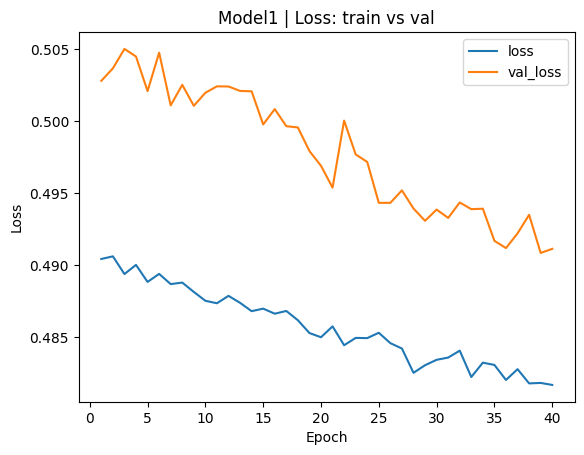

In [85]:
plt.figure()  # loss fig
plt.plot(epochs, history1.history["loss"])  # train loss
plt.plot(epochs, history1.history["val_loss"])  # val loss
plt.xlabel("Epoch")  # x label
plt.ylabel("Loss")  # y label
plt.title("Model1 | Loss: train vs val")  # title
plt.legend(["loss", "val_loss"])  # legend
plt.show()  # show

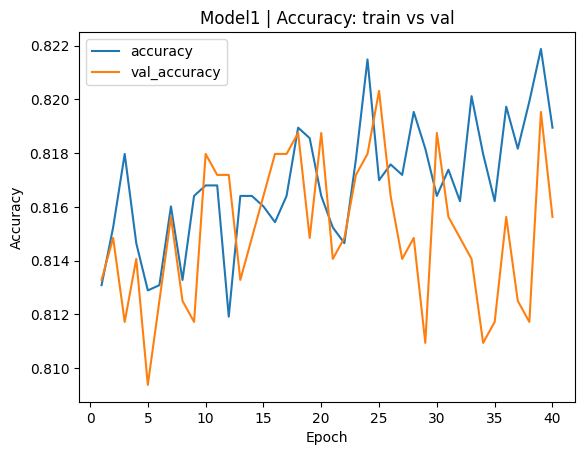

In [86]:
plt.figure()  # acc fig
plt.plot(epochs, history1.history["accuracy"])  # train acc
plt.plot(epochs, history1.history["val_accuracy"])  # val acc
plt.xlabel("Epoch")  # x label
plt.ylabel("Accuracy")  # y label
plt.title("Model1 | Accuracy: train vs val")  # title
plt.legend(["accuracy", "val_accuracy"])  # legend
plt.show()  # show

Predykcja na testowym

In [87]:
yhat_model1 = model1.predict(X_test)
yhat_model1[:10]

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[4.99919930e-04, 9.72256064e-01, 2.72440258e-02],
       [7.81049311e-01, 9.00413021e-02, 1.28909275e-01],
       [6.45589223e-03, 7.00758457e-01, 2.92785615e-01],
       [1.21499404e-01, 7.32385874e-01, 1.46114573e-01],
       [8.88109356e-02, 4.26617600e-02, 8.68527234e-01],
       [2.55404785e-02, 9.44930673e-01, 2.95288861e-02],
       [6.13593161e-01, 1.75059829e-02, 3.68900806e-01],
       [6.40722454e-01, 3.01937819e-01, 5.73396645e-02],
       [5.85197005e-03, 9.77768838e-01, 1.63791142e-02],
       [6.96112275e-01, 2.48152971e-01, 5.57347760e-02]], dtype=float32)

Metryki na testowym

In [88]:
test_loss, test_acc = model1.evaluate(X_test, y_test_ohe, verbose=0)
print("test_loss:", test_loss)
print("test_accuracy:", test_acc)

test_loss: 0.5433854460716248
test_accuracy: 0.7962499856948853


#Model 2

crossentropy

In [89]:
model2 = krs.models.Sequential()
model2.add(krs.layers.Dense(8, activation="relu", input_shape=(X_train.shape[1],)))
model2.add(krs.layers.Dense(4, activation="relu"))
model2.add(krs.layers.Dense(3, activation="softmax"))
model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219 (876.00 B)

 Trainable params: 219 (876.00 B)

 Non-trainable params: 0 (0.00 B)

In [90]:
assert model2.input_shape == (None, X_train.shape[1])
assert model2.layers[0].weights[0].shape == (X_train.shape[1], 8)
assert model2.layers[0].activation == krs.activations.relu

assert model2.layers[1].weights[0].shape == (8, 4)
assert model2.layers[1].activation == krs.activations.relu

assert model2.layers[2].weights[0].shape == (4, 3)
assert model2.layers[2].activation == krs.activations.softmax

Cross entropy nie chce one-hot na testowym !

In [91]:
history2 = model2.fit(
    X_train.values,
    y_train.values,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1)

Epoch 1/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3482 - loss: 1.1418 - val_accuracy: 0.4203 - val_loss: 1.0534
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4181 - loss: 1.0587 - val_accuracy: 0.5000 - val_loss: 1.0094
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4726 - loss: 1.0138 - val_accuracy: 0.5500 - val_loss: 0.9617
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5474 - loss: 0.9685 - val_accuracy: 0.5813 - val_loss: 0.9122
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5662 - loss: 0.9343 - val_accuracy: 0.6094 - val_loss: 0.8702
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6028 - loss: 0.8835 - val_accuracy: 0.6383 - val_loss: 0.8376
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6266 - loss: 0.8559 - val_accuracy: 0.6359 - val_loss: 0.8136
Epoch 8/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6276 - loss: 0.8413 - val_accuracy: 0.

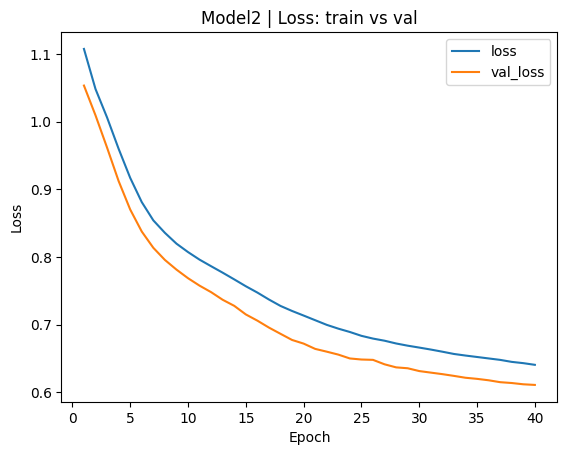

In [92]:
plt.figure()  # loss fig
plt.plot(epochs, history2.history["loss"])  # train loss
plt.plot(epochs, history2.history["val_loss"])  # val loss
plt.xlabel("Epoch")  # x label
plt.ylabel("Loss")  # y label
plt.title("Model2 | Loss: train vs val")  # title
plt.legend(["loss", "val_loss"])  # legend
plt.show()  # show

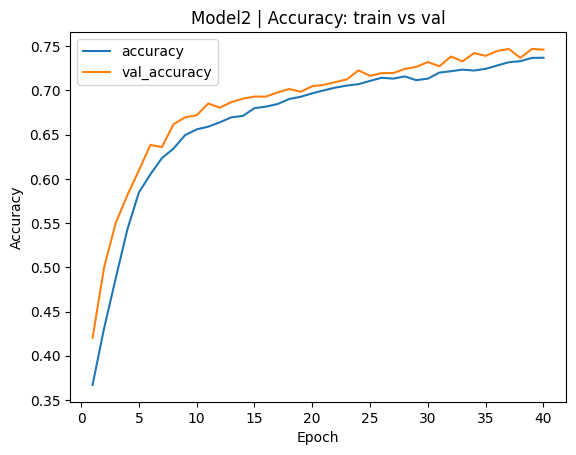

In [93]:
plt.figure()  # acc fig
plt.plot(epochs, history2.history["accuracy"])  # train acc
plt.plot(epochs, history2.history["val_accuracy"])  # val acc
plt.xlabel("Epoch")  # x label
plt.ylabel("Accuracy")  # y label
plt.title("Model2 | Accuracy: train vs val")  # title
plt.legend(["accuracy", "val_accuracy"])  # legend
plt.show()  # show

Predykcja na testowym

In [94]:
yhat_model2 = model2.predict(X_test)
yhat_model2[:10]

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[1.3948780e-03, 9.9437815e-01, 4.2270096e-03],
       [7.7102184e-01, 1.0994065e-01, 1.1903745e-01],
       [8.7292112e-02, 5.5686677e-01, 3.5584104e-01],
       [2.3520185e-01, 3.4108400e-01, 4.2371425e-01],
       [1.2960540e-01, 5.1819384e-01, 3.5220075e-01],
       [1.5363365e-01, 7.2502398e-01, 1.2134230e-01],
       [8.2410663e-01, 9.7333558e-04, 1.7492010e-01],
       [2.6073459e-01, 6.8060446e-01, 5.8660973e-02],
       [8.3287142e-02, 7.0081955e-01, 2.1589325e-01],
       [9.4702482e-02, 8.7482613e-01, 3.0471342e-02]], dtype=float32)

In [96]:
test_loss, test_acc = model2.evaluate(X_test, y_test.values, verbose=0)
print("test_loss:", test_loss)
print("test_accuracy:", test_acc)

test_loss: 0.6368639469146729
test_accuracy: 0.7325000166893005


#Model 3

Regularyzacja

In [97]:
model3 = krs.models.Sequential()
model3.add(krs.layers.Dense(8, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=krs.regularizers.l2(1e-3)))
model3.add(krs.layers.Dense(4, activation="relu", kernel_regularizer=krs.regularizers.l2(1e-3)))
model3.add(krs.layers.Dense(3, activation="softmax"))
model3.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 8)              │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 219 (876.00 B)

 Trainable params: 219 (876.00 B)

 Non-trainable params: 0 (0.00 B)

In [98]:
history3 = model3.fit(
    X_train,
    y_train_ohe,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1)

Epoch 1/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3820 - loss: 1.1191 - val_accuracy: 0.4187 - val_loss: 1.0808
Epoch 2/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4233 - loss: 1.0840 - val_accuracy: 0.4563 - val_loss: 1.0367
Epoch 3/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4787 - loss: 1.0338 - val_accuracy: 0.5055 - val_loss: 0.9916
Epoch 4/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4977 - loss: 0.9955 - val_accuracy: 0.5312 - val_loss: 0.9458
Epoch 5/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5544 - loss: 0.9457 - val_accuracy: 0.5742 - val_loss: 0.8919
Epoch 6/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5892 - loss: 0.8908 - val_accuracy: 0.6313 - val_loss: 0.8425
Epoch 7/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6330 - loss: 0.8468 - val_accuracy: 0.6633 - val_loss: 0.8037
Epoch 8/40
160/160 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6292 - loss: 0.8352 - val_accuracy: 0.

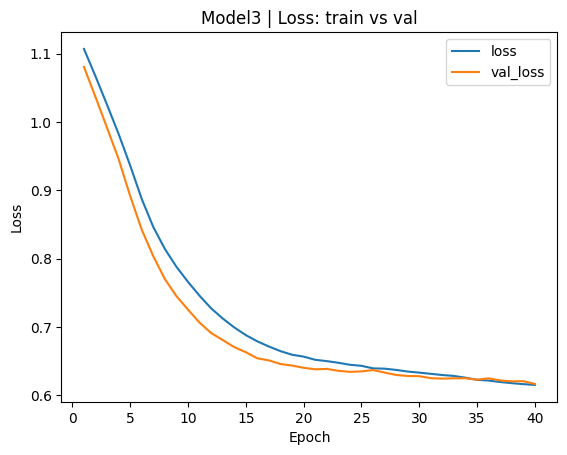

In [99]:
plt.figure()  # loss fig
plt.plot(epochs, history3.history["loss"])  # train loss
plt.plot(epochs, history3.history["val_loss"])  # val loss
plt.xlabel("Epoch")  # x label
plt.ylabel("Loss")  # y label
plt.title("Model3 | Loss: train vs val")  # title
plt.legend(["loss", "val_loss"])  # legend
plt.show()  # show

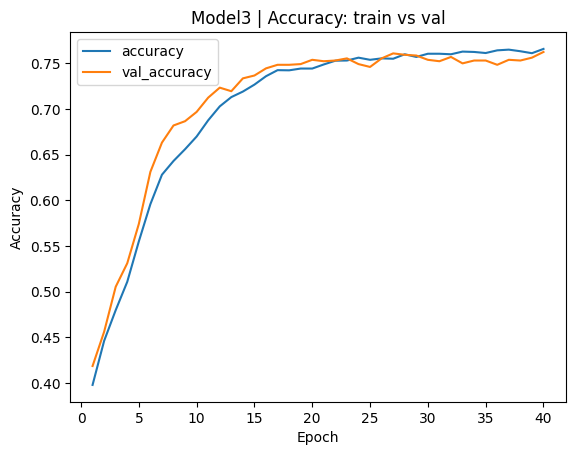

In [100]:
plt.figure()  # acc fig
plt.plot(epochs, history3.history["accuracy"])  # train acc
plt.plot(epochs, history3.history["val_accuracy"])  # val acc
plt.xlabel("Epoch")  # x label
plt.ylabel("Accuracy")  # y label
plt.title("Model3 | Accuracy: train vs val")  # title
plt.legend(["accuracy", "val_accuracy"])  # legend
plt.show()  # show

In [101]:
yhat_model3 = model3.predict(X_test)
yhat_model3[:10]

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[2.2649335e-02, 9.7172123e-01, 5.6294180e-03],
       [6.3503391e-01, 1.8142028e-01, 1.8354575e-01],
       [7.1787997e-03, 7.1667778e-01, 2.7614340e-01],
       [4.0492287e-04, 3.6476469e-01, 6.3483042e-01],
       [2.9826647e-02, 2.9837602e-01, 6.7179728e-01],
       [2.3068469e-03, 4.6410236e-01, 5.3359073e-01],
       [7.6807171e-01, 3.1987089e-04, 2.3160836e-01],
       [3.9314127e-01, 2.1859866e-01, 3.8826007e-01],
       [1.3006069e-02, 9.6743923e-01, 1.9554665e-02],
       [5.9231341e-01, 3.7866989e-01, 2.9016759e-02]], dtype=float32)

In [102]:
test_loss, test_acc = model3.evaluate(X_test, y_test_ohe, verbose=0)
print("test_loss:", test_loss)
print("test_accuracy:", test_acc)

test_loss: 0.667372465133667
test_accuracy: 0.7368749976158142


#Model 4

Dropout